In [1]:
import sympy as sp
from sympy import *
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols
from numpy import deg2rad, rad2deg, pi
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.spatial.transform import Rotation as R
from scipy.optimize import least_squares
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.optimize import approx_fprime
from scipy.spatial.transform import Rotation as Rot

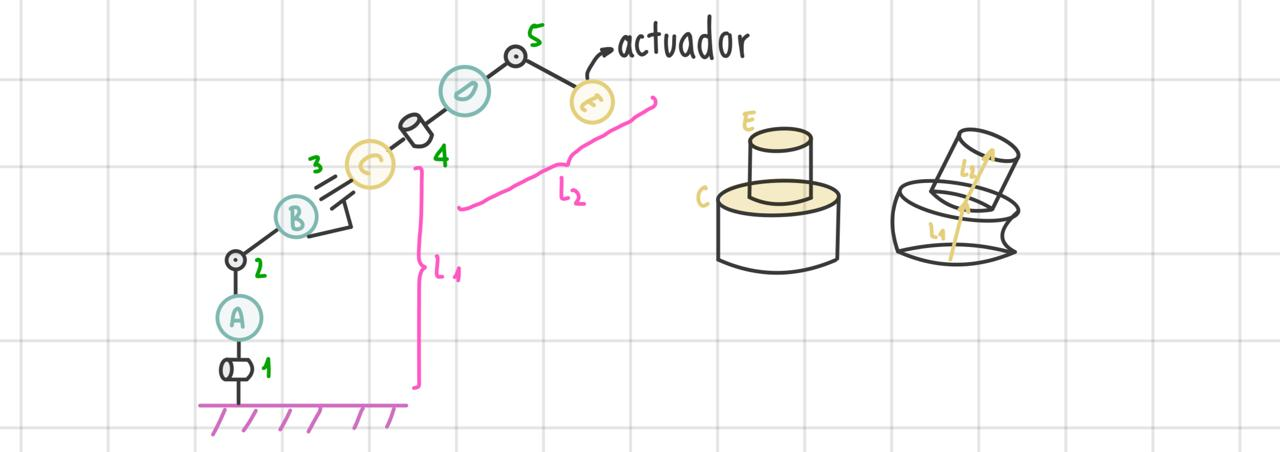

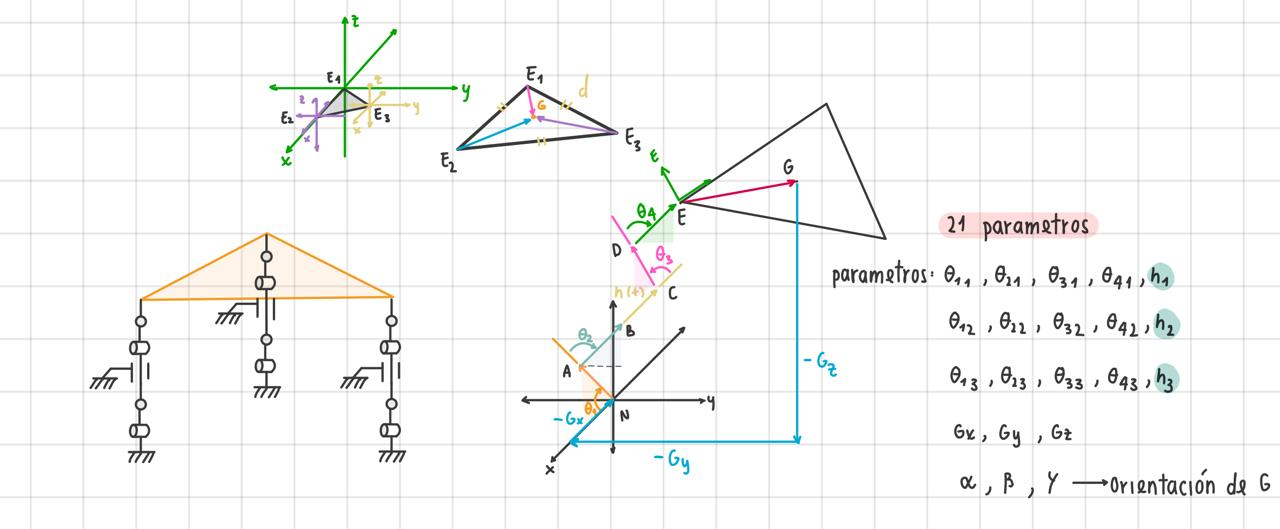

Ecuaciones de Loop de vectores

In [2]:
N = ReferenceFrame('N')
L2=symbols("L_2")
d=symbols("d")
Gx, Gy, Gz = symbols('Gx Gy Gz')

def loop_eqs(n):
    #longitud del lado del triangulo equilatero

    if n == 1:
        Ox = 0
        Oy = 0
    if n == 2:
        Ox = d
        Oy = 0
    if n == 3:
        Ox = d/2
        Oy = d*sqrt(3)/2

    #orientacion de los vectores
    theta1 = dynamicsymbols(f'theta1_{n}')
    theta2 = dynamicsymbols(f'theta2_{n}')
    theta3 = dynamicsymbols(f'theta3_{n}')
    theta4 = dynamicsymbols(f'theta4_{n}')

    #longitud de los vectores
    h = dynamicsymbols(f'h{n}')

    #orientacion de los vectores
    A= N.orientnew(f'A_{n}','Axis',[theta1, N.y])
    B = A.orientnew(f'B_{n}','Axis',[theta2, A.x])
    D = B.orientnew(f'D_{n}','Axis',[theta3, B.y])
    E = D.orientnew(f'E_{n}','Axis',[theta4, D.x])

    
    l_1=12*10**-3*B.x-h*B.x
    l_2=L2*E.x
    if n == 1:
        l_3 = -d/(2*sqrt(3))*E.x + d/2*E.y  
    if n == 2:
        l_3 = -d/(2*sqrt(3))*E.x - d/2*E.y
    if n == 3:
        l_3 =  d/sqrt(3)*E.x

    points = {
    "O": [Ox, Oy, 0],
    "B": [Ox + l_1.dot(N.x),   Oy + l_1.dot(N.y),   l_1.dot(N.z)],
    "E": [Ox + (l_1+l_2).dot(N.x), Oy + (l_1+l_2).dot(N.y), (l_1+l_2).dot(N.z)],
    "G": [Gx, Gy, Gz]
    }
    loop=l_1+l_2+l_3-Gx*N.x-Gy*N.y-Gz*N.z+(Ox*N.x+Oy*N.y) #l1,l2 y l3, (Gx,Gy,Gz) son las coordenadas del centroide, (Ox,Oy) son las coordenadas del origen de cada brazo

    eqsX = loop.dot(N.x)
    eqsY = loop.dot(N.y)
    eqsZ = loop.dot(N.z)
    
    return eqsX, eqsY, eqsZ, points, A, E

brazo1 = loop_eqs(1)
brazo2 = loop_eqs(2)
brazo3 = loop_eqs(3)

eqs_brazo1=[brazo1[0], brazo1[1], brazo1[2]]
eqs_brazo2=[brazo2[0], brazo2[1], brazo2[2]]
eqs_brazo3=[brazo3[0], brazo3[1], brazo3[2]]

eqs_totales = eqs_brazo1 + eqs_brazo2 + eqs_brazo3

brazo1_points = brazo1[3]
brazo2_points = brazo2[3]
brazo3_points = brazo3[3]
brazo1_points

eqs_brazo1

[-Gx + d*((sin(theta1_1(t))*cos(theta2_1(t))*cos(theta3_1(t)) + sin(theta3_1(t))*cos(theta1_1(t)))*sin(theta4_1(t)) + sin(theta1_1(t))*sin(theta2_1(t))*cos(theta4_1(t)))/2 + (0.012 - h1(t))*cos(theta1_1(t)) + (L_2 - sqrt(3)*d/6)*(-sin(theta1_1(t))*sin(theta3_1(t))*cos(theta2_1(t)) + cos(theta1_1(t))*cos(theta3_1(t))),
 -Gy + d*(-sin(theta2_1(t))*sin(theta4_1(t))*cos(theta3_1(t)) + cos(theta2_1(t))*cos(theta4_1(t)))/2 + (L_2 - sqrt(3)*d/6)*sin(theta2_1(t))*sin(theta3_1(t)),
 -Gz + d*((-sin(theta1_1(t))*sin(theta3_1(t)) + cos(theta1_1(t))*cos(theta2_1(t))*cos(theta3_1(t)))*sin(theta4_1(t)) + sin(theta2_1(t))*cos(theta1_1(t))*cos(theta4_1(t)))/2 - (0.012 - h1(t))*sin(theta1_1(t)) + (L_2 - sqrt(3)*d/6)*(-sin(theta1_1(t))*cos(theta3_1(t)) - sin(theta3_1(t))*cos(theta1_1(t))*cos(theta2_1(t)))]

Genero funciones numericas

In [3]:

t1_1,t2_1,t3_1,t4_1 = symbols('t1_1 t2_1 t3_1 t4_1')
t1_2,t2_2,t3_2,t4_2 = symbols('t1_2 t2_2 t3_2 t4_2')
t1_3,t2_3,t3_3,t4_3 = symbols('t1_3 t2_3 t3_3 t4_3')
h1s, h2s, h3s        = symbols('h1s h2s h3s')

L2_val = 8*10**-3#m
d_val=30*10**-3#m

# Dynamicsymbols de cada brazo
th1 = dynamicsymbols('theta1_1 theta2_1 theta3_1 theta4_1 h1')
th2 = dynamicsymbols('theta1_2 theta2_2 theta3_2 theta4_2 h2')
th3 = dynamicsymbols('theta1_3 theta2_3 theta3_3 theta4_3 h3')

#cambio de variables para sustituir en las ecuaciones
subs_dict = {
    th1[0]: t1_1, th1[1]: t2_1, th1[2]: t3_1, th1[3]: t4_1, th1[4]: h1s,
    th2[0]: t1_2, th2[1]: t2_2, th2[2]: t3_2, th2[3]: t4_2, th2[4]: h2s,
    th3[0]: t1_3, th3[1]: t2_3, th3[2]: t3_3, th3[3]: t4_3, th3[4]: h3s,
}

# Incógnitas y parámetros para lambdify
incognitas  = [t1_1,t2_1,t3_1,t4_1, t1_2,t2_2,t3_2,t4_2, t1_3,t2_3,t3_3,t4_3, Gx,Gy,Gz]
parametros  = [h1s, h2s, h3s, L2, d]

# Sustituir y lambdify las 9 ecuaciones de posición
eqs_all_subs = [eq.subs(subs_dict) for eq in
                list(eqs_totales)]

f_pos = lambdify(incognitas + parametros, eqs_all_subs, modules='numpy')

# Lambdify matrices de rotación (frame E de cada brazo)
R1_sym = brazo1[-1].dcm(N).subs(subs_dict)
R2_sym = brazo2[-1].dcm(N).subs(subs_dict)
R3_sym = brazo3[-1].dcm(N).subs(subs_dict)

#funciones para obtener las matrices de rotación a partir de los ángulos
f_R1 = lambdify([t1_1,t2_1,t3_1,t4_1], R1_sym, modules='numpy')
f_R2 = lambdify([t1_2,t2_2,t3_2,t4_2], R2_sym, modules='numpy')
f_R3 = lambdify([t1_3,t2_3,t3_3,t4_3], R3_sym, modules='numpy')

brazo1_points_subs = {}
brazo2_points_subs = {}
brazo3_points_subs = {}

brazo1_points_subs['O']={brazo1_points['O'][0], brazo1_points['O'][1], brazo1_points['O'][2]}
brazo2_points_subs['O']={brazo2_points['O'][0], brazo2_points['O'][1], brazo2_points['O'][2]}
brazo3_points_subs['O']={brazo3_points['O'][0], brazo3_points['O'][1], brazo3_points['O'][2]}

brazo1_points_subs['B']={brazo1_points['B'][0].subs(subs_dict), brazo1_points['B'][1].subs(subs_dict), brazo1_points['B'][2].subs(subs_dict)}
brazo1_points_subs['E']={brazo1_points['E'][0].subs(subs_dict), brazo1_points['E'][1].subs(subs_dict), brazo1_points['E'][2].subs(subs_dict)}
brazo1_points_subs['G']={brazo1_points['G'][0].subs(subs_dict), brazo1_points['G'][1].subs(subs_dict), brazo1_points['G'][2].subs(subs_dict)}

brazo2_points_subs['B']={brazo2_points['B'][0].subs(subs_dict), brazo2_points['B'][1].subs(subs_dict), brazo2_points['B'][2].subs(subs_dict)}
brazo2_points_subs['E']={brazo2_points['E'][0].subs(subs_dict), brazo2_points['E'][1].subs(subs_dict), brazo2_points['E'][2].subs(subs_dict)}
brazo2_points_subs['G']={brazo2_points['G'][0].subs(subs_dict), brazo2_points['G'][1].subs(subs_dict), brazo2_points['G'][2].subs(subs_dict)}   

brazo3_points_subs['B']={brazo3_points['B'][0].subs(subs_dict), brazo3_points['B'][1].subs(subs_dict), brazo3_points['B'][2].subs(subs_dict)}
brazo3_points_subs['E']={brazo3_points['E'][0].subs(subs_dict), brazo3_points['E'][1].subs(subs_dict), brazo3_points['E'][2].subs(subs_dict)}
brazo3_points_subs['G']={brazo3_points['G'][0].subs(subs_dict), brazo3_points['G'][1].subs(subs_dict), brazo3_points['G'][2].subs(subs_dict)}


# LAMBDIFY DIRECTO DE LOS PUNTOS 

# Sustituir en los puntos simbólicos
f_O1 = np.array([float(brazo1_points['O'][0].subs({d: d_val}) if hasattr(brazo1_points['O'][0], 'subs') else brazo1_points['O'][0]),
                 float(brazo1_points['O'][1].subs({d: d_val}) if hasattr(brazo1_points['O'][1], 'subs') else brazo1_points['O'][1]),
                 float(brazo1_points['O'][2])])

f_O2 = np.array([float(brazo2_points['O'][0].subs({d: d_val})),
                 float(brazo2_points['O'][1]),
                 float(brazo2_points['O'][2])])

f_O3 = np.array([float(brazo3_points['O'][0].subs({d: d_val})),
                 float(brazo3_points['O'][1].subs({d: d_val})),
                 float(brazo3_points['O'][2])])

# Lambdify de B y E para cada brazo
# Brazo 1: depende de t1_1,t2_1,t3_1,t4_1 y h1s
brazo1_B_subs = [brazo1_points['B'][k].subs(subs_dict).subs({L2: L2_val, d: d_val}) for k in range(3)]
brazo1_E_subs = [brazo1_points['E'][k].subs(subs_dict).subs({L2: L2_val, d: d_val}) for k in range(3)]

brazo2_B_subs = [brazo2_points['B'][k].subs(subs_dict).subs({L2: L2_val, d: d_val}) for k in range(3)]
brazo2_E_subs = [brazo2_points['E'][k].subs(subs_dict).subs({L2: L2_val, d: d_val}) for k in range(3)]

brazo3_B_subs = [brazo3_points['B'][k].subs(subs_dict).subs({L2: L2_val, d: d_val}) for k in range(3)]
brazo3_E_subs = [brazo3_points['E'][k].subs(subs_dict).subs({L2: L2_val, d: d_val}) for k in range(3)]

# Lambdify — brazo 1 depende de [t1_1,t2_1,t3_1,t4_1, h1s]
f_B1 = lambdify([t1_1,t2_1,t3_1,t4_1,h1s], brazo1_B_subs, modules='numpy')
f_E1 = lambdify([t1_1,t2_1,t3_1,t4_1,h1s], brazo1_E_subs, modules='numpy')

f_B2 = lambdify([t1_2,t2_2,t3_2,t4_2,h2s], brazo2_B_subs, modules='numpy')
f_E2 = lambdify([t1_2,t2_2,t3_2,t4_2,h2s], brazo2_E_subs, modules='numpy')

f_B3 = lambdify([t1_3,t2_3,t3_3,t4_3,h3s], brazo3_B_subs, modules='numpy')
f_E3 = lambdify([t1_3,t2_3,t3_3,t4_3,h3s], brazo3_E_subs, modules='numpy')

# Expresiones simbólicas de l3 para cada brazo
th1_syms = dynamicsymbols('theta1_1 theta2_1 theta3_1 theta4_1')
th2_syms = dynamicsymbols('theta1_2 theta2_2 theta3_2 theta4_2')
th3_syms = dynamicsymbols('theta1_3 theta2_3 theta3_3 theta4_3')

# Entonces:
G1x_sym = (eqs_brazo1[0] + Gx).subs(subs_dict).subs({L2: L2_val, d: d_val})
G1y_sym = (eqs_brazo1[1] + Gy).subs(subs_dict).subs({L2: L2_val, d: d_val})
G1z_sym = (eqs_brazo1[2] + Gz).subs(subs_dict).subs({L2: L2_val, d: d_val})

G2x_sym = (eqs_brazo2[0] + Gx).subs(subs_dict).subs({L2: L2_val, d: d_val})
G2y_sym = (eqs_brazo2[1] + Gy).subs(subs_dict).subs({L2: L2_val, d: d_val})
G2z_sym = (eqs_brazo2[2] + Gz).subs(subs_dict).subs({L2: L2_val, d: d_val})

G3x_sym = (eqs_brazo3[0] + Gx).subs(subs_dict).subs({L2: L2_val, d: d_val})
G3y_sym = (eqs_brazo3[1] + Gy).subs(subs_dict).subs({L2: L2_val, d: d_val})
G3z_sym = (eqs_brazo3[2] + Gz).subs(subs_dict).subs({L2: L2_val, d: d_val})

# Lambdify — G de cada brazo solo depende de sus thetas y su h
f_G1 = lambdify([t1_1,t2_1,t3_1,t4_1, h1s], [G1x_sym, G1y_sym, G1z_sym], modules='numpy')
f_G2 = lambdify([t1_2,t2_2,t3_2,t4_2, h2s], [G2x_sym, G2y_sym, G2z_sym], modules='numpy')
f_G3 = lambdify([t1_3,t2_3,t3_3,t4_3, h3s], [G3x_sym, G3y_sym, G3z_sym], modules='numpy')


Ecuaciones de matrices de Rotacion

In [4]:
def residuos(x, H1, H2, H3):
    
    # 9 ecuaciones de posición
    r_pos = list(f_pos(*x, H1, H2, H3, L2_val, d_val))

    # 6 ecuaciones de orientación con cuaterniones — sin singularidades
    R1 = np.array(f_R1(x[0],x[1],x[2],x[3])).astype(float)
    R2 = np.array(f_R2(x[4],x[5],x[6],x[7])).astype(float)
    R3 = np.array(f_R3(x[8],x[9],x[10],x[11])).astype(float)

    q1 = Rot.from_matrix(R1).as_quat()  # [x, y, z, w]
    q2 = Rot.from_matrix(R2).as_quat()
    q3 = Rot.from_matrix(R3).as_quat()

    # Igualar q1=q2 y q1=q3 — solo 3 componentes (x,y,z)
    # porque w queda determinado por la normalización |q|=1
    r_ang = [
        q1[0] - q2[0],
        q1[1] - q2[1],
        q1[2] - q2[2],
        q1[0] - q3[0],
        q1[1] - q3[1],
        q1[2] - q3[2],
    ]

    return r_pos + r_ang  # 15 residuos

Resolver el Sistema

In [5]:


def resolver(H1, H2, H3, initial_guess, lb=None, ub=None):
    """
    H1, H2, H3     : alturas que controlas
    initial_guess  : lista de 15 valores [thetas x12, Gx, Gy, Gz]
    bounds         : límites para los ángulos (por defecto -π a π)
    """
    # Bounds: ángulos entre 0 y 2π, Gx/Gy/Gz sin límite
    if lb is None:
        lb = [-np.pi/2]*12       + [-0.05, -0.05, -0.05]   # G máximo 50mm en cualquier dirección
    if ub is None:
        ub = [np.pi/2]*12   + [ 0.05,  0.05,  0.05]

    resultado = least_squares(
        residuos,
        initial_guess,
        args=(H1, H2, H3),
        bounds=(lb, ub),
        method='trf',        # Trust Region Reflective — robusto con bounds
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
        max_nfev=50000,
        verbose=1            # muestra progreso
    )

    sol = resultado.x
    costo = resultado.cost
    exito = resultado.success

    print(f"\n{'Convergió' if exito else ' No convergió'} — costo final: {costo:.2e}")
    print(f"Residuo máximo: {np.max(np.abs(resultado.fun)):.2e}")

    return {
        "theta_brazo1_deg": np.degrees(sol[0:4]),
        "theta_brazo2_deg": np.degrees(sol[4:8]),
        "theta_brazo3_deg": np.degrees(sol[8:12]),
        "G": {"Gx": sol[12], "Gy": sol[13], "Gz": sol[14]},
        "raw": sol,
        "resultado_completo": resultado,
    }

H1, H2, H3= 0*10**-3, 0*10**-3, 0*10**-3 # alturas que controlas (en metros)
    
"""
initial guess = [t1_1,t2_1,t3_1,t4_1,  ← brazo 1  (índices 0-3)
                t1_2,t2_2,t3_2,t4_2,  ← brazo 2  (índices 4-7)
                t1_3,t2_3,t3_3,t4_3,  ← brazo 3  (índices 8-11)
                Gx, Gy, Gz]            ← centroide (índices 12-14)
"""
# Initial guess NO singular
ig_t = np.deg2rad(30)
G1_ig = np.array(f_G1(ig_t, ig_t, ig_t, ig_t, H1), dtype=float)
G2_ig = np.array(f_G2(ig_t, ig_t, ig_t, ig_t, H2), dtype=float)
G3_ig = np.array(f_G3(ig_t, ig_t, ig_t, ig_t, H3), dtype=float)
G_ig  = (G1_ig + G2_ig + G3_ig) / 3

initial_guess = [ig_t, ig_t, ig_t, ig_t,
                 ig_t, ig_t, ig_t, ig_t,
                 ig_t, ig_t, ig_t, ig_t,
                 G_ig[0], G_ig[1], G_ig[2]]

res = resolver(H1, H2, H3, initial_guess)

print("\n========== RESULTADOS ==========")
print(f"Thetas brazo 1 [°]: {res['theta_brazo1_deg']}")
print(f"Thetas brazo 2 [°]: {res['theta_brazo2_deg']}")
print(f"Thetas brazo 3 [°]: {res['theta_brazo3_deg']}")
print(f"Punto G: {res['G']}")

# Prueba con ángulos no nulos para evitar la singularidad
ig_t = np.deg2rad(0)  # 30° — fuera de la singularidad

# Verifica Jacobiano
J = approx_fprime(np.array(initial_guess),
                  lambda x: residuos(x, H1, H2, H3), 1e-7)
print(f"Rango: {np.linalg.matrix_rank(J)}")
print(f"Filas ~0: {[i for i,row in enumerate(J) if np.linalg.norm(row)<1e-6]}")
print(f"Columnas ~0: {[i for i,col in enumerate(J.T) if np.linalg.norm(col)<1e-6]}")

res = resolver(H1, H2, H3, initial_guess)


`gtol` termination condition is satisfied.
Function evaluations 147, initial cost 7.3327e-04, final cost 1.7973e-14, first-order optimality 2.53e-13.

Convergió — costo final: 1.80e-14
Residuo máximo: 1.07e-07

========== RESULTADOS ==========
Thetas brazo 1 [°]: [-1.72062809e-02  8.99999990e+01 -8.99996481e+01 -9.00000000e+01]
Thetas brazo 2 [°]: [-6.02219760e-02 -8.99999997e+01  8.99996472e+01  8.99569843e+01]
Thetas brazo 3 [°]: [-3.87225191e-02 -8.99999961e+01  8.99996490e+01  8.99784838e+01]
Punto G: {'Gx': np.float64(0.02700004568783106), 'Gy': np.float64(0.0006602539591576566), 'Gz': np.float64(8.108312739564869e-06)}
Rango: 15
Filas ~0: []
Columnas ~0: []
`gtol` termination condition is satisfied.
Function evaluations 147, initial cost 7.3327e-04, final cost 1.7973e-14, first-order optimality 2.53e-13.

Convergió — costo final: 1.80e-14
Residuo máximo: 1.07e-07


Graficar

O1=[0. 0. 0.] mm  B1=[1.19999995e+01 0.00000000e+00 3.60367498e-03] mm  E1=[ 1.20000486e+01 -8.00000000e+00  3.60382702e-03] mm
O2=[30.  0.  0.] mm  B2=[4.19999934e+01 0.00000000e+00 1.26128588e-02] mm  E2=[ 4.20000426e+01 -8.00000000e+00  1.26128707e-02] mm
O3=[15.         25.98076211  0.        ] mm  B3=[2.69999973e+01 2.59807621e+01 8.11002482e-03] mm  E3=[2.70000463e+01 1.79807621e+01 8.10951725e-03] mm
G solver = [2.70000457e+01 6.60253959e-01 8.10831274e-03] mm


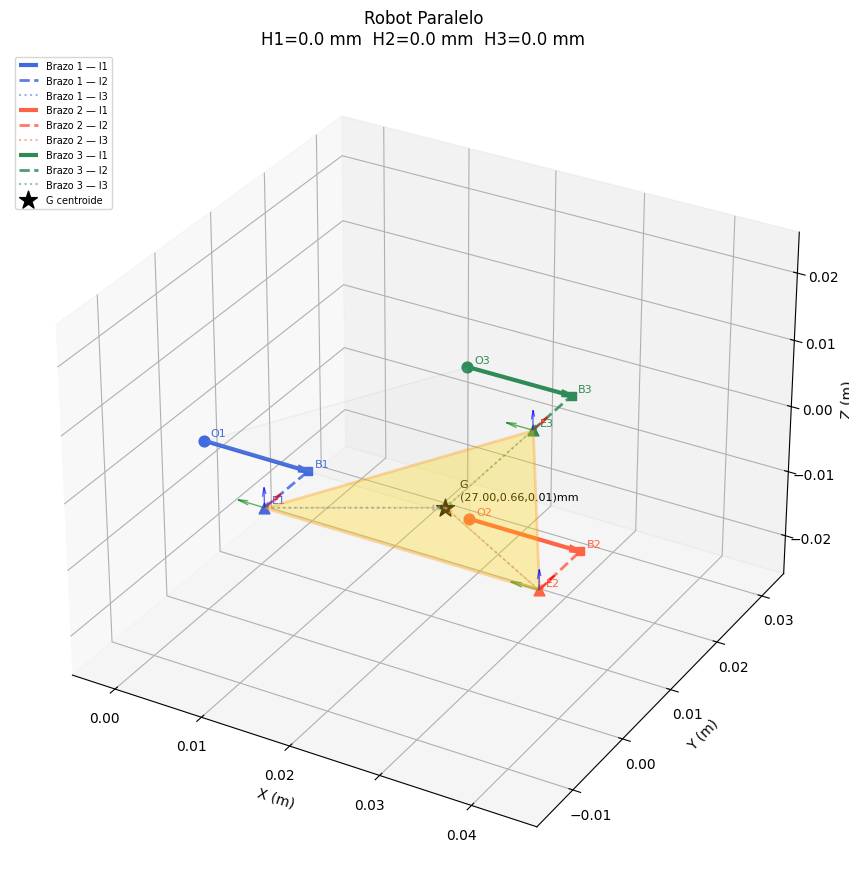

In [6]:


def graficar_robot(sol, H1, H2, H3, titulo="Robot Paralelo"):

    O1, O2, O3 = f_O1, f_O2, f_O3

    B1 = np.array(f_B1(sol[0],sol[1],sol[2],sol[3], H1), dtype=float)
    E1 = np.array(f_E1(sol[0],sol[1],sol[2],sol[3], H1), dtype=float)
    B2 = np.array(f_B2(sol[4],sol[5],sol[6],sol[7], H2), dtype=float)
    E2 = np.array(f_E2(sol[4],sol[5],sol[6],sol[7], H2), dtype=float)
    B3 = np.array(f_B3(sol[8],sol[9],sol[10],sol[11], H3), dtype=float)
    E3 = np.array(f_E3(sol[8],sol[9],sol[10],sol[11], H3), dtype=float)

    G = sol[12:15]

    print(f"O1={O1*1e3} mm  B1={B1*1e3} mm  E1={E1*1e3} mm")
    print(f"O2={O2*1e3} mm  B2={B2*1e3} mm  E2={E2*1e3} mm")
    print(f"O3={O3*1e3} mm  B3={B3*1e3} mm  E3={E3*1e3} mm")
    print(f"G solver = {G*1e3} mm")

    colores = ['royalblue', 'tomato', 'seagreen']
    nombres = ['Brazo 1', 'Brazo 2', 'Brazo 3']
    Os = [O1, O2, O3]
    Bs = [B1, B2, B3]
    Es = [E1, E2, E3]

    fig = plt.figure(figsize=(13, 9))
    ax  = fig.add_subplot(111, projection='3d')

    for i, (O, B, E, color, nombre) in enumerate(zip(Os, Bs, Es, colores, nombres)):
        ax.quiver(*O, *(B-O), color=color, linewidth=3,
                  arrow_length_ratio=0.1, label=f'{nombre} — l1')
        ax.quiver(*B, *(E-B), color=color, linewidth=2,
                  arrow_length_ratio=0.1, linestyle='dashed',
                  alpha=0.85, label=f'{nombre} — l2')

        # l3: desde E hasta G
        ax.quiver(*E, *(G-E), color=color, linewidth=1.5,
                  arrow_length_ratio=0.08, linestyle='dotted',
                  alpha=0.5, label=f'{nombre} — l3')

        ax.scatter(*O, color=color, s=60,  zorder=5)
        ax.scatter(*B, color=color, s=40,  marker='s', zorder=5)
        ax.scatter(*E, color=color, s=60,  marker='^', zorder=6)

        offset = np.array([0.0005, 0.0005, 0.0005])
        ax.text(*(O+offset), f'O{i+1}', fontsize=8, color=color)
        ax.text(*(B+offset), f'B{i+1}', fontsize=8, color=color)
        ax.text(*(E+offset), f'E{i+1}', fontsize=8, color=color)

        R_E = np.array(f_R1(sol[0],sol[1],sol[2],sol[3]) if i==0 else
                       f_R2(sol[4],sol[5],sol[6],sol[7]) if i==1 else
                       f_R3(sol[8],sol[9],sol[10],sol[11])).astype(float)
        for vec, ec in zip(R_E.T, ['red','green','blue']):
            ax.quiver(*E, *(0.003*vec), color=ec, linewidth=1,
                      arrow_length_ratio=0.4, alpha=0.6)

    # Triángulo entre E1, E2, E3
    puntas_E = np.array([E1, E2, E3])
    ax.add_collection3d(Poly3DCollection([puntas_E], alpha=0.3,
                        facecolor='gold', edgecolor='darkorange', linewidth=2))

    # --- G ---
    ax.scatter(*G, color='black', s=180, marker='*', zorder=7, label='G centroide')
    ax.text(*(G + 0.001), f"G\n({G[0]*1e3:.2f},{G[1]*1e3:.2f},{G[2]*1e3:.2f})mm",
            fontsize=8, color='black')

    # Líneas desde G a cada vértice E
    for E_pt in [E1, E2, E3]:
        ax.plot(*zip(G, E_pt), color='gray', lw=0.8, linestyle='--', alpha=0.5)

    # Base
    ax.add_collection3d(Poly3DCollection([np.array([O1,O2,O3])], alpha=0.08,
                        facecolor='lightgray', edgecolor='gray'))

    # Escala uniforme — incluye G
    todos = np.vstack([Os, Bs, Es, [G]])
    centro = (todos.max(0) + todos.min(0)) / 2
    r = np.max(todos.max(0) - todos.min(0)) / 2 + 0.005
    ax.set_xlim(centro[0]-r, centro[0]+r)
    ax.set_ylim(centro[1]-r, centro[1]+r)
    ax.set_zlim(centro[2]-r, centro[2]+r)

    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
    ax.set_title(f'{titulo}\nH1={H1*1e3:.1f} mm  H2={H2*1e3:.1f} mm  H3={H3*1e3:.1f} mm')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(dict(zip(labels,handles)).values(),
              dict(zip(labels,handles)).keys(), loc='upper left', fontsize=7)
    plt.tight_layout()
    plt.show()

graficar_robot(res['raw'], H1, H2, H3)

In [7]:

sol = res['raw']

G1 = np.array(f_G1(sol[0],sol[1],sol[2],sol[3], H1), dtype=float)
G2 = np.array(f_G2(sol[4],sol[5],sol[6],sol[7], H2), dtype=float)
G3 = np.array(f_G3(sol[8],sol[9],sol[10],sol[11], H3), dtype=float)

print(f"G desde brazo 1: {G1*1e3} mm")
print(f"G desde brazo 2: {G2*1e3} mm")
print(f"G desde brazo 3: {G3*1e3} mm")
print(f"Error G1-G2: {np.linalg.norm(G1-G2)*1e3:.4f} mm")
print(f"Error G1-G3: {np.linalg.norm(G1-G3)*1e3:.4f} mm")
print(f"G del solver:   {sol[12:15]*1e3} mm")
print(f"Error G1-solver: {np.linalg.norm(G1-sol[12:15])*1e3:.4f} mm")

G desde brazo 1: [2.69999947e+01 6.60346177e-01 8.10826018e-03] mm
G desde brazo 2: [2.69999900e+01 6.60161662e-01 8.10826017e-03] mm
G desde brazo 3: [2.70001524e+01 6.60254038e-01 8.10841835e-03] mm
Error G1-G2: 0.0002 mm
Error G1-G3: 0.0002 mm
G del solver:   [2.70000457e+01 6.60253959e-01 8.10831274e-03] mm
Error G1-solver: 0.0001 mm


In [8]:
# Verifica con la solución actual
sol = res['raw']
R1 = np.array(f_R1(sol[0],sol[1],sol[2],sol[3])).astype(float)
R2 = np.array(f_R2(sol[4],sol[5],sol[6],sol[7])).astype(float)
R3 = np.array(f_R3(sol[8],sol[9],sol[10],sol[11])).astype(float)

roll1,pitch1,yaw1 = R.from_matrix(R1).as_euler('xyz', degrees=True)
roll2,pitch2,yaw2 = R.from_matrix(R2).as_euler('xyz', degrees=True)
roll3,pitch3,yaw3 = R.from_matrix(R3).as_euler('xyz', degrees=True)

print(f"Brazo 1: roll={roll1:.4f}° pitch={pitch1:.4f}° yaw={yaw1:.4f}°")
print(f"Brazo 2: roll={roll2:.4f}° pitch={pitch2:.4f}° yaw={yaw2:.4f}°")
print(f"Brazo 3: roll={roll3:.4f}° pitch={pitch3:.4f}° yaw={yaw3:.4f}°")
print(f"\nDif pitch 1-2: {abs(pitch1-pitch2):.6f}°")
print(f"Dif pitch 2-3: {abs(pitch2-pitch3):.6f}°")
print(f"Dif yaw 1-2:   {abs(yaw1-yaw2):.6f}°")
print(f"Dif roll 1-2:  {abs(roll1-roll2):.6f}°")

Brazo 1: roll=0.0000° pitch=0.0172° yaw=89.9996°
Brazo 2: roll=-0.0000° pitch=0.0172° yaw=89.9996°
Brazo 3: roll=-0.0000° pitch=0.0172° yaw=89.9996°

Dif pitch 1-2: 0.000000°
Dif pitch 2-3: 0.000000°
Dif yaw 1-2:   0.000001°
Dif roll 1-2:  0.000001°


In [9]:

R1 = np.array(f_R1(sol[0],sol[1],sol[2],sol[3])).astype(float)
R2 = np.array(f_R2(sol[4],sol[5],sol[6],sol[7])).astype(float)
R3 = np.array(f_R3(sol[8],sol[9],sol[10],sol[11])).astype(float)

print("R1:\n", np.round(R1, 4))
print("R2:\n", np.round(R2, 4))
print("R3:\n", np.round(R3, 4))
print("\nR1-R2:\n", np.round(R1-R2, 6))
print("R1-R3:\n", np.round(R1-R3, 6))

R1:
 [[ 0.e+00 -1.e+00  0.e+00]
 [ 1.e+00  0.e+00  3.e-04]
 [-3.e-04  0.e+00  1.e+00]]
R2:
 [[ 0.e+00 -1.e+00  0.e+00]
 [ 1.e+00  0.e+00  3.e-04]
 [-3.e-04 -0.e+00  1.e+00]]
R3:
 [[ 0.e+00 -1.e+00 -0.e+00]
 [ 1.e+00  0.e+00  3.e-04]
 [-3.e-04 -0.e+00  1.e+00]]

R1-R2:
 [[-0. -0.  0.]
 [ 0. -0.  0.]
 [-0.  0. -0.]]
R1-R3:
 [[ 0.  0.  0.]
 [-0.  0. -0.]
 [ 0.  0.  0.]]


In [10]:
# Con thetas=0, E.x=+Nz, E.y=?, E.z=?
R1_0 = np.array(f_R1(0,0,0,0)).astype(float)
print("E.x en N:", R1_0[:,0])  # debe ser [0,0,1]
print("E.y en N:", R1_0[:,1])  # dirección del triángulo
print("E.z en N:", R1_0[:,2])  # dirección del triángulo

E.x en N: [1. 0. 0.]
E.y en N: [ 0.  1. -0.]
E.z en N: [-0.  0.  1.]
